In [ ]:
# import libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
# load dataset
df = pd.read_csv('cosmetic_process_optimisation.csv')
df.head()

,Batch_ID,Formula_Type,Mixing_Temperature,Viscosity_cP,pH,Stability_Days
0,BATCH_001,Surfactant_Boosted,High_60C,2415.35,6.94,11
1,BATCH_002,Standard,Low_35C,2500.59,6.57,13
2,BATCH_003,Surfactant_Boosted,Low_35C,2013.79,6.84,17
3,BATCH_004,Surfactant_Boosted,High_60C,2398.89,7.12,10
4,BATCH_005,Standard,High_60C,2683.70,6.72,8


In [ ]:
# grouping by formula type and mixing temperature to get the average af the three outcomes

chemical_averages = df.groupby(['Formula_Type', "Mixing_Temperature"]).mean(numeric_only=True)
print(chemical_averages)

                                       Viscosity_cP        pH  Stability_Days
Formula_Type       Mixing_Temperature                                        
Organic_Polymer    High_60C             3547.208000  6.370500       14.950000
                   Low_35C              3334.588000  6.296000       19.900000
Standard           High_60C             2815.191765  6.616471       10.000000
                   Low_35C              2503.185000  6.523636       14.636364
Surfactant_Boosted High_60C             2392.711176  7.041765       12.000000
                   Low_35C              2127.294583  6.861667       16.041667


Multivariant analysis


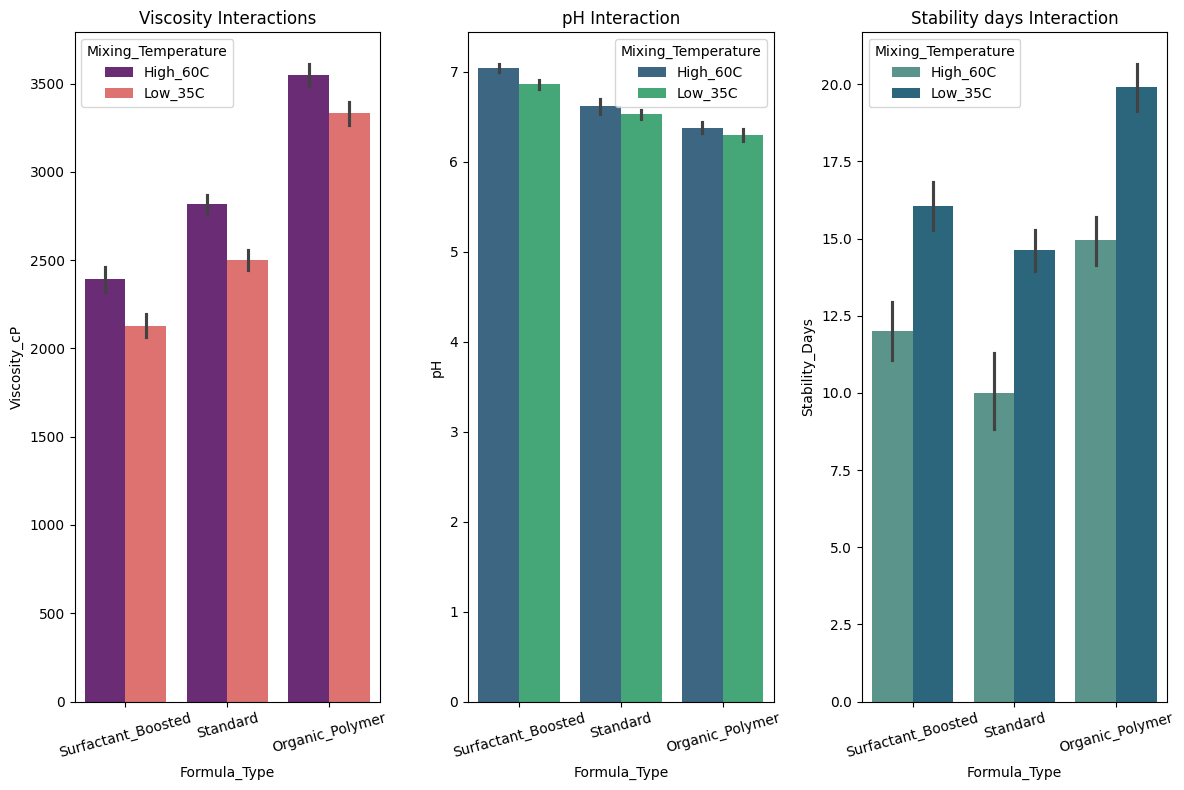

In [14]:
# visualise the outcome
plt.figure(figsize=(12, 8))

# To see how formula and temperature interacts when viscocity changes
plt.subplot(1, 3, 1)
sns.barplot(data=df, x='Formula_Type', y='Viscosity_cP' , hue='Mixing_Temperature', palette='magma' )
plt.title("Viscosity Interactions")
plt.xticks(rotation=15)

# when ph changes 
plt.subplot(1, 3, 2)
sns.barplot(data=df, x='Formula_Type', y='pH', hue='Mixing_Temperature', palette='viridis')
plt.title('pH Interaction')
plt.xticks(rotation=15)

# at different stability days
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='Formula_Type', y='Stability_Days', hue='Mixing_Temperature', palette='crest')
plt.title('Stability days Interaction')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("process optimisation.png")
print('Multivariant analysis')

In [18]:
# using monova to check whether there is a significant difference between the groups
from statsmodels.multivariate.manova import MANOVA

moav = MANOVA.from_formula('Viscosity_cP + pH + Stability_Days ~ Formula_Type * Mixing_Temperature', data=df)

# Printing the multivariate test results
print(moav.mv_test())

                      Multivariate linear model
                                                                      
----------------------------------------------------------------------
           Intercept         Value   Num DF  Den DF   F Value   Pr > F
----------------------------------------------------------------------
              Wilks' lambda   0.0023 3.0000 112.0000 16553.3269 0.0000
             Pillai's trace   0.9977 3.0000 112.0000 16553.3269 0.0000
     Hotelling-Lawley trace 443.3927 3.0000 112.0000 16553.3269 0.0000
        Roy's greatest root 443.3927 3.0000 112.0000 16553.3269 0.0000
----------------------------------------------------------------------
                                                                      
-----------------------------------------------------------------------
          Formula_Type       Value   Num DF   Den DF   F Value   Pr > F
-----------------------------------------------------------------------
              Wilks' lambd